# CelebA-HQ Diffusion Pipeline

This notebook implements a diffusion model pipeline for generating human faces using the CelebA-HQ 256x256 dataset.

We begin with dataset loading and visualization before moving to preprocessing and training.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

print("Notebook cwd:", Path.cwd())
print("Project root:", PROJECT_ROOT)

import matplotlib.pyplot as plt
import torch

from src.celeba_dataset import CelebAHQDataset

Notebook cwd: /user/HS402/km02098/Documents/Applied ML/eee068-diffusion-face-generation/notebooks
Project root: /user/HS402/km02098/Documents/Applied ML/eee068-diffusion-face-generation


## Dataset

We use the CelebA-HQ dataset (256×256 RGB face images) for training a diffusion model.

In [2]:
CELEBA_PATH = PROJECT_ROOT / "celeba_hq_256"

dataset = CelebAHQDataset(CELEBA_PATH)

print("Total images:", len(dataset))
print("Sample image size:", dataset[0]["images"].size)

Loaded 30000 images from /user/HS402/km02098/Documents/Applied ML/eee068-diffusion-face-generation/celeba_hq_256
Total images: 30000
Sample image size: (256, 256)


## Data Inspection

We visualise a few samples to verify image quality and consistency before preprocessing.

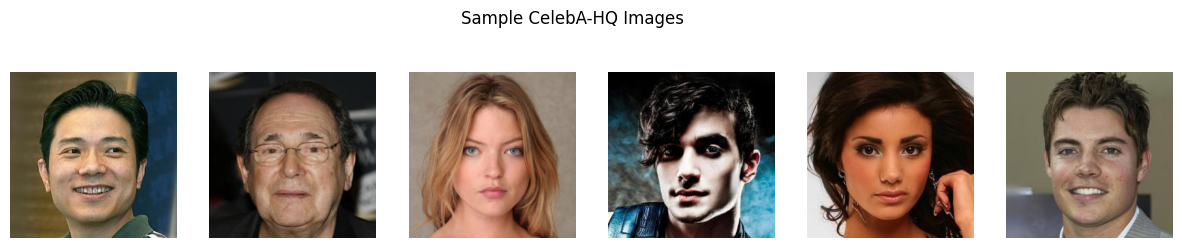

In [3]:
fig, axs = plt.subplots(1, 6, figsize=(15, 3))

for i in range(6):
    img = dataset[i]["images"]
    axs[i].imshow(img)
    axs[i].axis("off")

plt.suptitle("Sample CelebA-HQ Images")
plt.show()

## Train-Test Split

To evaluate model performance, we split the dataset into:
- Training set
- Test set

We use a fixed random seed to ensure reproducibility.

For this project:
- Training set: 2700 images
- Test set: 300 images

In [4]:
from torch.utils.data import random_split, Subset

subset_size = 3000
train_size = 2700
test_size = 300

project_dataset = Subset(dataset, range(subset_size))

train_dataset, test_dataset = random_split(
    project_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Project subset size:", len(project_dataset))
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Project subset size: 3000
Train size: 2700
Test size: 300


## Next Step: Preprocessing

The dataset currently returns raw PIL images. 
In the next stage, preprocessing will be applied including:
- Resizing to 256×256
- Normalization to [-1, 1]
- Data augmentation (horizontal flipping)

These transformations will be incorporated via PyTorch transforms and DataLoader.

In [5]:
from torchvision import transforms
from torch.utils.data import DataLoader, Subset, random_split

FACE_SIZE = 256
BATCH_SIZE = 16

transform = transforms.Compose([
    transforms.Resize((FACE_SIZE, FACE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

dataset = CelebAHQDataset(CELEBA_PATH, transform=transform)

subset_size = 3000
train_size = 2700
test_size = 300

assert len(dataset) >= subset_size, f"Need at least 3000 images, found {len(dataset)}"

project_dataset = Subset(dataset, range(subset_size))

train_dataset, test_dataset = random_split(
    project_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Project subset size:", len(project_dataset))
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))
print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Loaded 30000 images from /user/HS402/km02098/Documents/Applied ML/eee068-diffusion-face-generation/celeba_hq_256
Project subset size: 3000
Train size: 2700
Test size: 300
Train batches: 169
Test batches: 19
